# 🧠 Day 10 — Neural Networks from Scratch
### NumPy Only · 2 Hours

---

**The rule for today:** No PyTorch. No TensorFlow. No Keras.

Every single computation — forward pass, loss, gradients, weight updates — will be written by hand using NumPy arrays and the maths from the slides. This is the most important session of the course because it turns neural networks from a black box into something you actually understand.

**What you will build:**

| Task | What it does |
|------|--------------|
| Perceptron | Single neuron with step activation |
| Activation functions | Sigmoid, Tanh, ReLU, Leaky ReLU + derivatives |
| Weight initialisation | Zero vs random — prove why zeros fail |
| Forward pass | 2-layer network, step by step |
| BCE loss | Binary cross-entropy implemented and tested |
| Gradient check | Prove your gradients are correct numerically |
| Backward pass | Full backpropagation using chain rule |
| Training loop | Forward → loss → backward → update |
| XOR solution | Train the network to learn XOR |
| Sigmoid vs ReLU | Compare convergence on the same problem |
| Vanishing gradients | Visualise gradient death in deep sigmoid networks |

---
> 💡 **If you get stuck:** Go back to the slides. Every equation in this notebook appears there first.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
np.random.seed(42)
print('Setup complete ✅  — NumPy only from here')

Setup complete ✅  — NumPy only from here


---
# Part 1 — The Perceptron

## The Simplest Possible Neural Network

A perceptron is one artificial neuron. It receives inputs, multiplies each by a weight, sums them up, adds a bias, and passes the result through an activation function.

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b$$

$$\hat{y} = \text{step}(z) = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{if } z < 0 \end{cases}$$

The perceptron can solve **linearly separable** problems — any problem where a straight line separates the two classes.

**The AND gate is linearly separable:**
```
X1=0, X2=0 → 0
X1=0, X2=1 → 0
X1=1, X2=0 → 0
X1=1, X2=1 → 1   ← only true when BOTH inputs are 1
```
A line can separate the single (1,1)=1 point from the three 0 points.

**XOR is NOT linearly separable** — no straight line can separate the outputs. We will prove this empirically.

In [3]:
# ── TASK 1 — Implement and test the Perceptron ───────────────────────────────
# Complete the Perceptron class below.
#
# forward(): compute z = X @ w + b, return step(z)
# train():   perceptron learning rule:
#              for each sample:
#                error = y_true - y_pred
#                w = w + lr * error * x
#                b = b + lr * error

class Perceptron:
    def __init__(self, n_features: int, learning_rate: float = 0.1):
        self.w  = np.zeros(n_features)
        self.b  = 0.0
        self.lr = learning_rate

    def _step(self, z: np.ndarray) -> np.ndarray:
        return (z >= 0).astype(int)

    def forward(self, X: np.ndarray) -> np.ndarray:
        """Compute predictions for all rows in X."""
        # YOUR CODE HERE
        return self._step(X @ self.w + self.b)

    def train(self, X: np.ndarray, y: np.ndarray, epochs: int = 20):
        """Train using the perceptron update rule."""
        # YOUR CODE HERE
        for _ in range(epochs):
            for x_i, y_i in zip(X,y):
                y_pred = self._step(x_i @ self.w + self.b)
                error = y_i - y_pred
                self.w += self.lr * error * x_i
                self.b += self.lr * error


# AND gate data
X_and = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_and = np.array([0, 0, 0, 1])

# XOR gate data
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

# Train and test on AND
p_and = Perceptron(n_features=2)
p_and.train(X_and, y_and, epochs=30)
print(f'AND gate predictions:  {p_and.forward(X_and)}  (expected: [0 0 0 1])')

# Train and test on XOR
p_xor = Perceptron(n_features=2)
p_xor.train(X_xor, y_xor, epochs=100)
print(f'XOR gate predictions:  {p_xor.forward(X_xor)}  (expected: [0 1 1 0])')
print(f'XOR solved? {np.array_equal(p_xor.forward(X_xor), y_xor)}')

# 📝 Can the perceptron solve XOR? What does this tell you about its limitations?
# ...

AND gate predictions:  [0 0 0 1]  (expected: [0 0 0 1])
XOR gate predictions:  [1 1 0 0]  (expected: [0 1 1 0])
XOR solved? False


---
# Part 2 — Activation Functions

## Why Activation Functions Exist

Without a non-linear activation function, stacking multiple layers of neurons is mathematically equivalent to a single linear transformation:

$$W_2 (W_1 x + b_1) + b_2 = (W_2 W_1) x + (W_2 b_1 + b_2) = W' x + b'$$

Two layers with no activation = one layer. Three layers = one layer. Depth becomes meaningless. Activation functions **break this linearity** and give neural networks the ability to learn complex, non-linear patterns.

## The Four Functions

### Sigmoid
$$\sigma(z) = \frac{1}{1+e^{-z}} \qquad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$
Output: 0 to 1. The derivative has a maximum of 0.25 — this is the root cause of vanishing gradients.

### Tanh
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} \qquad \tanh'(z) = 1 - \tanh^2(z)$$
Output: −1 to 1. Zero-centred — better than sigmoid for hidden layers, but still vanishes.

### ReLU
$$\text{ReLU}(z) = \max(0, z) \qquad \text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$
The derivative is 1 for all positive inputs — no shrinkage, no vanishing gradient for active neurons.

### Leaky ReLU
$$\text{LeakyReLU}(z) = \max(\alpha z, z) \quad (\alpha = 0.01) \qquad \text{derivative} = \begin{cases} 1 & z > 0 \\ 0.01 & z \leq 0 \end{cases}$$
Fixes the "dying ReLU" problem — neurons that get stuck outputting zero permanently.

In [4]:
# ── TASK 3 — Implement all four activations + their derivatives ───────────────
# Each function takes a NumPy array z and returns a NumPy array
# The derivative functions take z (NOT the activated value) and return dA/dz

def sigmoid(z: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z: np.ndarray) -> np.ndarray:
    """d/dz sigmoid(z) = sigmoid(z) * (1 - sigmoid(z))"""
    # YOUR CODE HERE
    return sigmoid(z) * (1 - sigmoid(z))

def tanh_activation(z: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE — use np.tanh
    return np.tanh(z)

def tanh_derivative(z: np.ndarray) -> np.ndarray:
    """d/dz tanh(z) = 1 - tanh²(z)"""
    # YOUR CODE HERE
    return 1 - np.square(tanh_activation(z))

def relu(z: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    return np.maximum(0, z)

def relu_derivative(z: np.ndarray) -> np.ndarray:
    """d/dz ReLU(z) = 1 if z>0 else 0"""
    # YOUR CODE HERE
    return (z>0).astype(float)

def leaky_relu(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    # YOUR CODE HERE
    return np.where(z>0, z, alpha*z)

def leaky_relu_derivative(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    # YOUR CODE HERE
    return np.where(z>0 , 1.0, alpha)

# Sanity checks
z_test = np.array([-5.0, -1.0, 0.0, 1.0, 5.0])
print('sigmoid:       ', np.round(sigmoid(z_test), 4))
print('sigmoid deriv: ', np.round(sigmoid_derivative(z_test), 4))
print('relu:          ', relu(z_test))
print('relu deriv:    ', relu_derivative(z_test))
print(f'sigmoid(0) = {sigmoid(np.array([0.0]))[0]:.4f}  (expected: 0.5)')
print(f'relu(-3)   = {relu(np.array([-3.0]))[0]:.4f}   (expected: 0.0)')
print(f'relu(3)    = {relu(np.array([3.0]))[0]:.4f}   (expected: 3.0)')

sigmoid:        [0.0067 0.2689 0.5    0.7311 0.9933]
sigmoid deriv:  [0.0066 0.1966 0.25   0.1966 0.0066]
relu:           [0. 0. 0. 1. 5.]
relu deriv:     [0. 0. 0. 1. 1.]
sigmoid(0) = 0.5000  (expected: 0.5)
relu(-3)   = 0.0000   (expected: 0.0)
relu(3)    = 3.0000   (expected: 3.0)


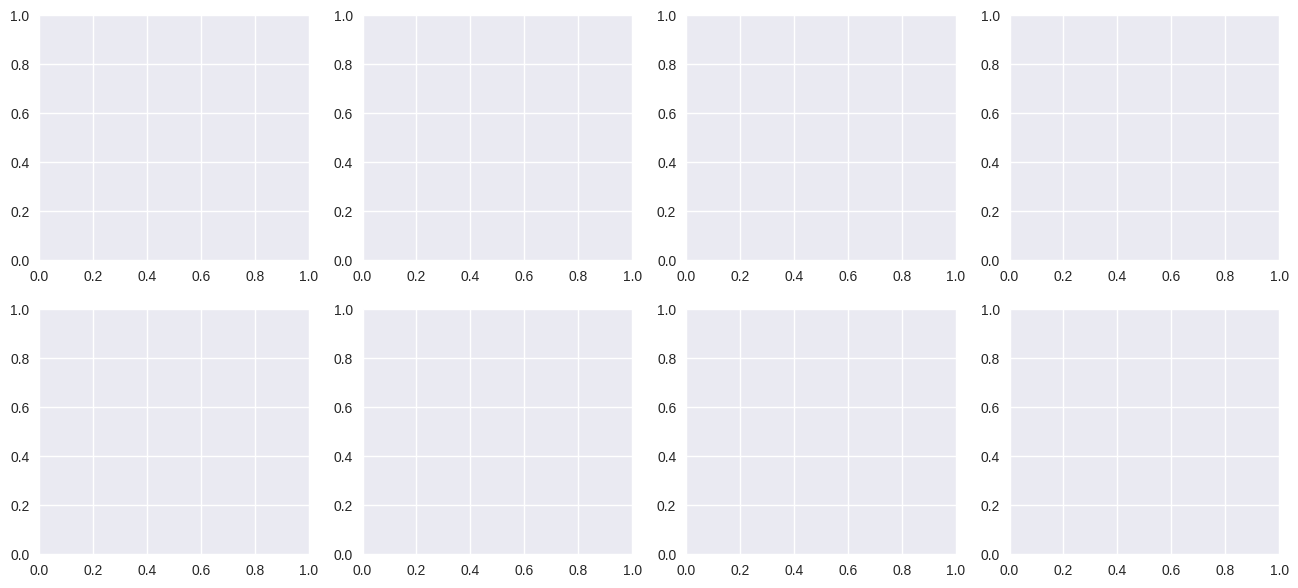

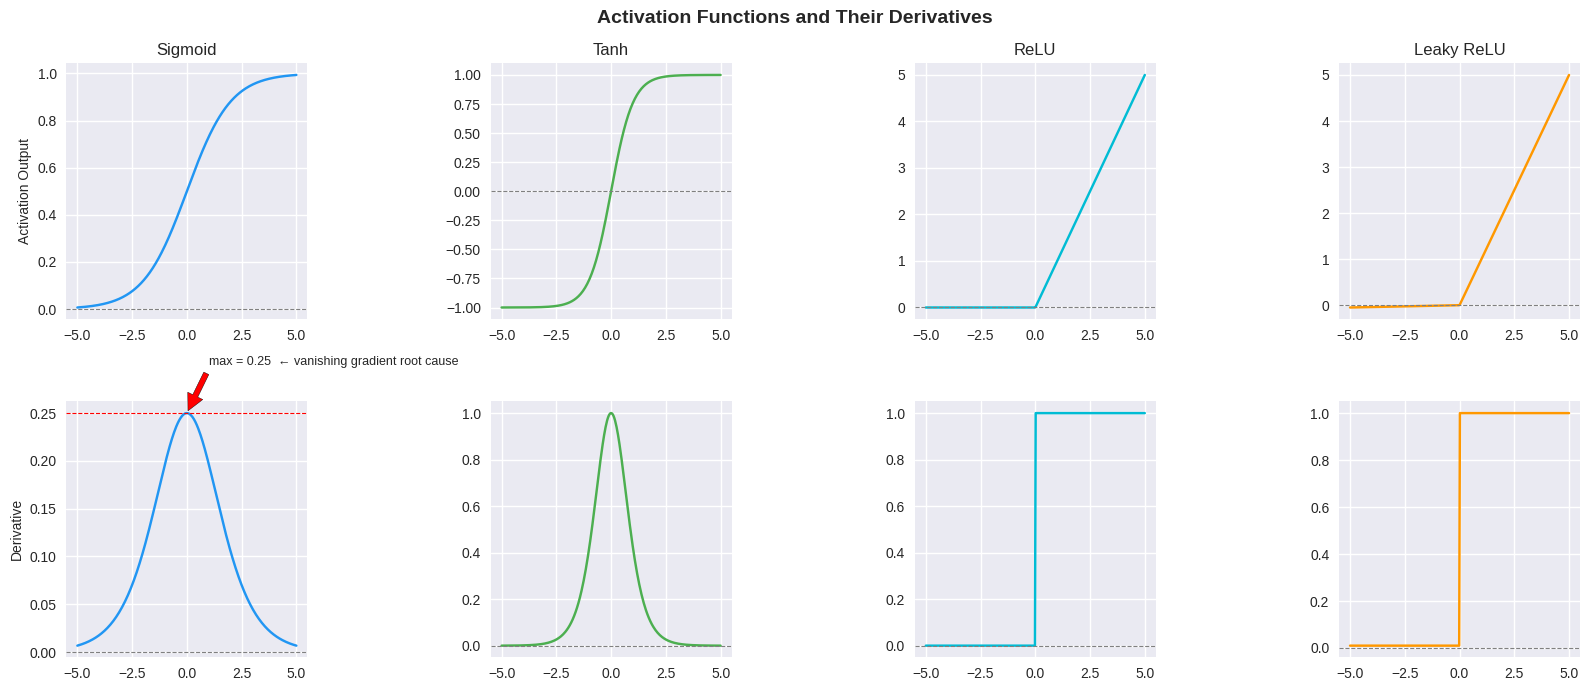

In [5]:
# ── TASK 4 — Plot all four activations + derivatives ─────────────────────────
# Create a 2×4 grid of subplots (figsize=(16, 7))
# Top row:    activation function curves for z in [-5, 5]
# Bottom row: derivative curves for the same z range
# Colour each function differently
# Add a horizontal dashed line at y=0 on each plot
# For the sigmoid derivative plot, add a horizontal dashed line at y=0.25
#   and annotate it: "max = 0.25  ← vanishing gradient root cause"

z = np.linspace(-5, 5, 300)

activations = [
    ('Sigmoid',     sigmoid(z),        sigmoid_derivative(z),     '#2196F3'),
    ('Tanh',        tanh_activation(z),tanh_derivative(z),        '#4CAF50'),
    ('ReLU',        relu(z),           relu_derivative(z),        '#00BCD4'),
    ('Leaky ReLU',  leaky_relu(z),     leaky_relu_derivative(z),  '#FF9800'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# YOUR CODE HERE
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, (name, act, deriv, color) in enumerate(activations):
    axes[0][i].plot(z, act, color=color, label=name)
    axes[1][i].plot(z, deriv, color=color, label=f'{name} Derivative')
    for ax in axes:
        ax[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    if name == 'Sigmoid':
        axes[1][i].axhline(0.25, color='red', linestyle='--', linewidth=0.8)
        axes[1][i].annotate('max = 0.25  ← vanishing gradient root cause',
                            xy=(0, 0.25), xytext=(1, 0.3),
                            arrowprops=dict(facecolor='red', shrink=0.05),
                            fontsize=9)
    axes[0][i].set_title(name, fontsize=12) 
    

axes[0][0].set_ylabel('Activation Output', fontsize=10)
axes[1][0].set_ylabel('Derivative', fontsize=10)
plt.suptitle('Activation Functions and Their Derivatives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 📝 Look at the sigmoid derivative curve.
# What is the maximum value? What happens in the tails (z far from 0)?
# Why does this cause problems in deep networks?
# ...

In [8]:
# ── TASK 5 — Demonstrate the vanishing gradient ───────────────────────────────
# Compute the sigmoid derivative at z = -10, -5, -2, 0, 2, 5, 10
# Print each value
# Then simulate 5 layers: start with gradient=1.0 at the output layer
#   and multiply by sigmoid_derivative(z) at each layer
# Use z=0.5 for all layers (a typical pre-activation value)
# Print the gradient magnitude at each layer

print('Sigmoid derivative at various z values:')
for z_val in [-10, -5, -2, 0, 2, 5, 10]:
    # YOUR CODE HERE
    d = sigmoid_derivative(np.array([z_val]))[0]
    print(f'z = {z_val}: derivative = {d}')

print('\nGradient magnitude through 5 sigmoid layers (z=0.5 each):')
# YOUR CODE HERE
gradient = 1.0
for layer in range(5, 0, -1):
    gradient *= sigmoid_derivative(np.array([0.5]))[0]
    print(f'Layer {layer}: gradient = {gradient:.8f}')


# 📝 By the time the gradient reaches layer 1, how much has it shrunk?
# If you had 20 layers, what would the gradient be at layer 1?
# ...

Sigmoid derivative at various z values:
z = -10: derivative = 4.5395807735951673e-05
z = -5: derivative = 0.006648056670790155
z = -2: derivative = 0.1049935854035065
z = 0: derivative = 0.25
z = 2: derivative = 0.10499358540350662
z = 5: derivative = 0.006648056670790033
z = 10: derivative = 4.5395807735907655e-05

Gradient magnitude through 5 sigmoid layers (z=0.5 each):
Layer 5: gradient = 0.23500371
Layer 4: gradient = 0.05522674
Layer 3: gradient = 0.01297849
Layer 2: gradient = 0.00304999
Layer 1: gradient = 0.00071676


---
# Part 3 — Weight Initialisation

## Why Zero Initialisation Fails — The Symmetry Problem

If all weights start at zero, every neuron in a layer computes **exactly the same thing**:

```
Neuron 1: z = w · x + b = 0 · x + 0 = 0
Neuron 2: z = w · x + b = 0 · x + 0 = 0
Neuron 3: z = w · x + b = 0 · x + 0 = 0
```

Same output → same gradient → same weight update → neurons stay identical forever. A 100-neuron layer behaves like a 1-neuron layer. You have wasted 99 neurons.

**Fix:** Initialise weights with small random values — typically `W = np.random.randn(...) * 0.01`. This **breaks symmetry**: each neuron starts slightly different and can specialise during training.

**Why multiply by 0.01?** To keep the initial activations in a reasonable range. Very large weights push sigmoid into its saturated (flat derivative) region immediately, causing vanishing gradients before training even begins.

In [10]:
# ── TASK 6 — Prove the symmetry problem ──────────────────────────────────────
# Build a tiny 2-hidden-neuron network with ZERO initialisation
# Input X = [[1, 2]] (one sample, two features)
#
# Forward pass:
#   z1 = X @ W1 + b1   (shape: 1×2)
#   a1 = sigmoid(z1)   (shape: 1×2)
#   z2 = a1 @ W2 + b2  (shape: 1×1)
#   a2 = sigmoid(z2)   (shape: 1×1)
#
# 1. Run forward pass with all-zero weights
# 2. Print z1 — show both hidden neurons get identical values
# 3. Run forward pass with random weights (np.random.randn * 0.01)
# 4. Print z1 — show neurons now differ

X_sym = np.array([[1.0, 2.0]])
y_sym = np.array([[1.0]])

# Zero initialisation
W1_zero = np.zeros((2, 2))
b1_zero = np.zeros((1, 2))
W2_zero = np.zeros((2, 1))
b2_zero = np.zeros((1, 1))

# Random initialisation
np.random.seed(42)
W1_rand = np.random.randn(2, 2) * 0.01
b1_rand = np.zeros((1, 2))
W2_rand = np.random.randn(2, 1) * 0.01
b2_rand = np.zeros((1, 1))

# YOUR CODE HERE — forward pass for both initialisations
z1_zero = X_sym @ W1_zero + b1_zero
a1_zero = sigmoid(z1_zero)
z2_zero = a1_zero @ W2_zero + b2_zero
a2_zero = sigmoid(z2_zero)

print('Zero init - z1:', z1_zero)
print('Random init - z1:', X_sym @ W1_rand + b1_rand)
print('zero init - a1:', a1_zero)
print('Random init - a1:', sigmoid(X_sym @ W1_rand + b1_rand))

# 📝 Are the hidden neuron activations identical with zero init?
# What happens during backprop if all neurons have identical activations?
# ...

Zero init - z1: [[0. 0.]]
Random init - z1: [[0.01792091 0.02907795]]
zero init - a1: [[0.5 0.5]]
Random init - a1: [[0.50448011 0.50726898]]


---
# Part 4 — Forward Pass

## The 2-Layer Network Architecture

We will use this architecture for the rest of the session:

```
Input Layer    Hidden Layer (ReLU)    Output Layer (Sigmoid)

   x₁  ─┐
         ├──→  h₁  ─┐
   x₂  ─┤    h₂  ─┤──→  ŷ  (probability)
         ├──→  h₃  ─┘
   x₃  ─┘    ...
```

**Forward pass equations:**

$$z_1 = X W_1 + b_1 \qquad a_1 = \text{ReLU}(z_1)$$
$$z_2 = a_1 W_2 + b_2 \qquad a_2 = \sigma(z_2)$$

**Shape tracking** — always know what shape you expect:

| Variable | Shape | Meaning |
|---------|-------|---------|
| X | (n_samples, n_features) | Input batch |
| W1 | (n_features, n_hidden) | Input-to-hidden weights |
| b1 | (1, n_hidden) | Hidden bias |
| z1, a1 | (n_samples, n_hidden) | Hidden pre/post-activation |
| W2 | (n_hidden, 1) | Hidden-to-output weights |
| b2 | (1, 1) | Output bias |
| z2, a2 | (n_samples, 1) | Output pre/post-activation |

In [11]:
# ── TASK 8 — Implement forward_pass() ────────────────────────────────────────
# Takes X and a params dict with keys: W1, b1, W2, b2
# Returns a dict with: z1, a1, z2, a2
# Also takes hidden_activation as a parameter (default='relu')
#   so we can swap to 'sigmoid' later for comparison

def forward_pass(X: np.ndarray, params: dict, hidden_activation: str = 'relu') -> dict:
    """
    2-layer neural network forward pass.
    Returns cache dict with z1, a1, z2, a2.
    """
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']

    # YOUR CODE HERE
    z1 = X @ W1 + b1
    a1 = relu(z1) if hidden_activation == 'relu' else sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return {'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}


# XOR dataset (we will solve this by the end of the session)
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

# Initialise parameters
def init_params(n_input: int, n_hidden: int, seed: int = 42) -> dict:
    np.random.seed(seed)
    return {
        'W1': np.random.randn(n_input, n_hidden) * 0.1,
        'b1': np.zeros((1, n_hidden)),
        'W2': np.random.randn(n_hidden, 1) * 0.1,
        'b2': np.zeros((1, 1)),
    }

params = init_params(n_input=2, n_hidden=4)

# ── TASK 9 — Run forward pass on XOR, print shapes and raw predictions ────────
# YOUR CODE HERE
cache = forward_pass(X_xor, params)
for k,v in cache.items():
    print(f'{k}: shape {v.shape}, values:\n{v}\n')
print(f'\n Untrained predictions (a2):\n{cache["a2"]}\n')

# 📝 Before training, what do the output probabilities look like?
# Are they close to the correct labels [0, 1, 1, 0]?
# ...

z1: shape (4, 4), values:
[[ 0.          0.          0.          0.        ]
 [-0.02341534 -0.0234137   0.15792128  0.07674347]
 [ 0.04967142 -0.01382643  0.06476885  0.15230299]
 [ 0.02625608 -0.03724013  0.22269014  0.22904646]]

a1: shape (4, 4), values:
[[0.         0.         0.         0.        ]
 [0.         0.         0.15792128 0.07674347]
 [0.04967142 0.         0.06476885 0.15230299]
 [0.02625608 0.         0.22269014 0.22904646]]

z2: shape (4, 1), values:
[[ 0.        ]
 [-0.01089252]
 [-0.01242665]
 [-0.02221989]]

a2: shape (4, 1), values:
[[0.5       ]
 [0.4972769 ]
 [0.49689338]
 [0.49444526]]


 Untrained predictions (a2):
[[0.5       ]
 [0.4972769 ]
 [0.49689338]
 [0.49444526]]



---
# Part 5 — Binary Cross-Entropy Loss

## The Right Loss for Classification

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \right]$$

**Why not MSE?** When the output uses sigmoid and the loss is MSE, the loss surface is non-convex — gradient descent can get stuck. Binary cross-entropy with sigmoid creates a **convex** loss surface, guaranteeing gradient descent finds the global minimum.

**Reading BCE:**

| Prediction | True label | BCE | Interpretation |
|-----------|-----------|-----|----------------|
| p = 0.99 | y = 1 | ≈ 0.01 | Confident and correct — tiny loss |
| p = 0.01 | y = 1 | ≈ 4.6 | Confident and WRONG — huge loss |
| p = 0.50 | y = 1 | ≈ 0.69 | Uncertain — log(2) ≈ 0.693 |

The maximum uncertainty (50/50) produces BCE = log(2) ≈ 0.693. This is why a completely untrained network starts with a loss near **0.693** — exactly what you will see when you train XOR.

> ⚠️ Always clip predictions away from exactly 0 and 1 — `np.log(0) = -∞` will crash your training.

In [12]:
# ── TASK 10 — Implement Binary Cross-Entropy loss ────────────────────────────
# Clip predictions to [1e-15, 1-1e-15] before applying log
# Return scalar mean loss over all samples

def binary_cross_entropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Compute binary cross-entropy loss.
    y_true: shape (n, 1)
    y_pred: shape (n, 1), values in (0, 1)
    """
    # YOUR CODE HERE
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


# Test on the three key cases
y_true_test = np.array([[1],[1],[0],[0]])
pred_correct   = np.array([[0.99],[0.95],[0.01],[0.05]])
pred_wrong     = np.array([[0.01],[0.05],[0.99],[0.95]])
pred_uncertain = np.array([[0.50],[0.50],[0.50],[0.50]])

print(f'Confident & correct:   BCE = {binary_cross_entropy(y_true_test, pred_correct):.4f}')
print(f'Confident & wrong:     BCE = {binary_cross_entropy(y_true_test, pred_wrong):.4f}')
print(f'Uncertain predictions: BCE = {binary_cross_entropy(y_true_test, pred_uncertain):.4f}  (expected ≈ 0.693)')

# 📝 An untrained network outputs ~0.5 for everything.
# What loss do you expect at the start of XOR training?
# ...

Confident & correct:   BCE = 0.0307
Confident & wrong:     BCE = 3.8005
Uncertain predictions: BCE = 0.6931  (expected ≈ 0.693)


ValueError: x and y must have same first dimension, but have shapes (300,) and (1,)

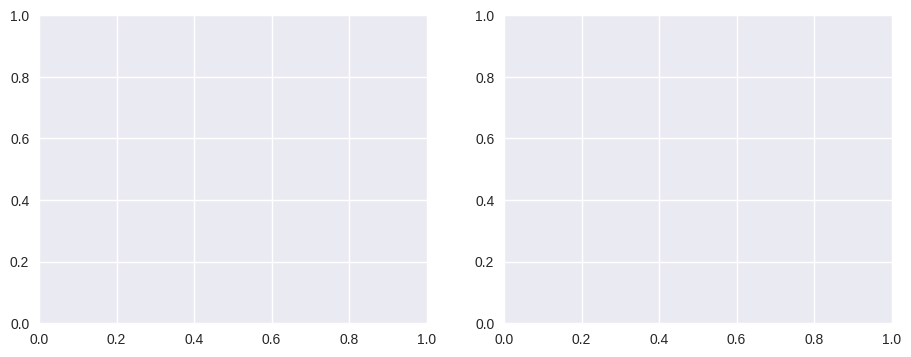

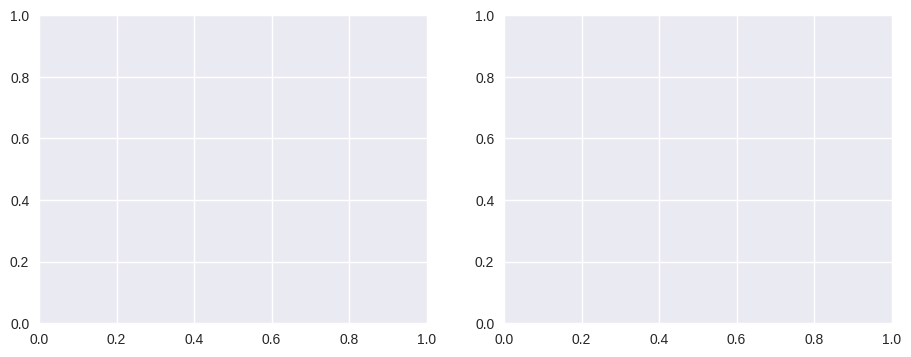

In [14]:
# ── TASK 11 — Plot BCE loss vs predicted probability ─────────────────────────
# Create 1×2 subplots (figsize=(11, 4))
# Left:  BCE loss when true label y=1, as p goes from 0.001 to 0.999
# Right: BCE loss when true label y=0, as p goes from 0.001 to 0.999
# Both curves should show: near-zero loss when correct, large loss when wrong
# Add a vertical dashed line at p=0.5 on each plot

p_vals = np.linspace(0.001, 0.999, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(p_vals, binary_cross_entropy(np.array([[1]]), p_vals.reshape(-1, 1)), color='blue')
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('BCE Loss when y=1', fontsize=12)
axes[0].set_xlabel('Predicted Probability p', fontsize=10)
axes[0].set_ylabel('Binary Cross-Entropy Loss', fontsize=10)  
axes[1].plot(p_vals, binary_cross_entropy(np.array([[0]]), p_vals.reshape(-1, 1)), color='orange')
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('BCE Loss when y=0', fontsize=12)
axes[1].set_xlabel('Predicted Probability p', fontsize=10)
axes[1].set_ylabel('Binary Cross-Entropy Loss', fontsize=10)



plt.suptitle('Binary Cross-Entropy Loss — Wrong predictions are punished exponentially', fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part 6 — Chain Rule & Backpropagation

## The Core Idea

We need to find $\frac{\partial \mathcal{L}}{\partial W_1}$ — how does changing $W_1$ affect the loss? But $W_1$ doesn't directly appear in the loss. The loss depends on $a_2$, which depends on $z_2$, which depends on $a_1$, which depends on $z_1$, which depends on $W_1$.

The chain rule connects them all:

$$\frac{\partial \mathcal{L}}{\partial W_1} = \frac{\partial \mathcal{L}}{\partial a_2} \cdot \frac{\partial a_2}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial W_1}$$

## The Six Gradient Steps

Step 1: $\frac{\partial \mathcal{L}}{\partial a_2} = -\frac{y}{a_2} + \frac{1-y}{1-a_2}$

Step 2: $\frac{\partial \mathcal{L}}{\partial z_2} = \frac{\partial \mathcal{L}}{\partial a_2} \times a_2(1-a_2) \quad$ ← simplified: $a_2 - y$

Step 3: $\frac{\partial \mathcal{L}}{\partial W_2} = a_1^T \cdot \frac{\partial \mathcal{L}}{\partial z_2}$

Step 4: $\frac{\partial \mathcal{L}}{\partial a_1} = \frac{\partial \mathcal{L}}{\partial z_2} \cdot W_2^T$

Step 5: $\frac{\partial \mathcal{L}}{\partial z_1} = \frac{\partial \mathcal{L}}{\partial a_1} \times \mathbf{1}[z_1 > 0] \quad$ ← ReLU derivative

Step 6: $\frac{\partial \mathcal{L}}{\partial W_1} = X^T \cdot \frac{\partial \mathcal{L}}{\partial z_1}$

> 💡 **The simplified Step 2:** When sigmoid is the output activation and BCE is the loss, the combined derivative simplifies beautifully to just $a_2 - y$. This is one reason why sigmoid + BCE is the standard pairing for binary classification.

In [ ]:
# ── TASK 12 — Numerical gradient check ───────────────────────────────────────
# Before implementing backprop, verify that your gradient formula is correct.
# Numerical gradient: (L(w+ε) - L(w-ε)) / (2ε)  for ε=1e-5
#
# Check the gradient of the loss with respect to W2[0,0] (one element)
# Compare numerical gradient to analytical gradient dL/dW2[0,0]
# They should match to at least 4 decimal places

eps = 1e-5
params_check = init_params(n_input=2, n_hidden=4, seed=0)

# Forward pass to get analytical gradient for W2[0,0]
cache = forward_pass(X_xor, params_check)
dz2_analytical = cache['a2'] - y_xor               # simplified sigmoid+BCE derivative
dW2_analytical = (cache['a1'].T @ dz2_analytical) / len(X_xor)

# Numerical gradient for W2[0,0]
# YOUR CODE HERE:
#   params_plus  = copy of params with W2[0,0] + eps
#   params_minus = copy of params with W2[0,0] - eps
#   loss_plus  = BCE of forward pass with params_plus
#   loss_minus = BCE of forward pass with params_minus
#   numerical_grad = (loss_plus - loss_minus) / (2 * eps)


print(f'Analytical dL/dW2[0,0]: {dW2_analytical[0,0]:.8f}')
# YOUR CODE HERE — print numerical gradient
# print(f'Numerical  dL/dW2[0,0]: {numerical_grad:.8f}')
# print(f'Difference:             {abs(dW2_analytical[0,0] - numerical_grad):.2e}')

# 📝 If the difference is less than 1e-5, your gradient is correct.
# ...

In [ ]:
# ── TASK 13 — Implement backward_pass() ──────────────────────────────────────
# Takes X, y, params, cache (from forward_pass), and hidden_activation
# Returns grads dict with: dW1, db1, dW2, db2
# Follow the 6 steps from the markdown above
#
# Important shapes:
#   dz2:  (n_samples, 1)     ← = a2 - y
#   dW2:  (n_hidden, 1)      ← = a1.T @ dz2 / n
#   db2:  (1, 1)             ← = mean of dz2
#   da1:  (n_samples, n_hid) ← = dz2 @ W2.T
#   dz1:  (n_samples, n_hid) ← = da1 * relu_derivative(z1)
#   dW1:  (n_input, n_hid)   ← = X.T @ dz1 / n
#   db1:  (1, n_hid)         ← = mean of dz1

def backward_pass(X: np.ndarray, y: np.ndarray, params: dict,
                  cache: dict, hidden_activation: str = 'relu') -> dict:
    """
    Compute gradients for all parameters using backpropagation.
    Returns dict with dW1, db1, dW2, db2.
    """
    n = X.shape[0]
    W2 = params['W2']
    a1, a2 = cache['a1'], cache['a2']
    z1 = cache['z1']

    # YOUR CODE HERE — implement all 6 steps
    pass


print('backward_pass defined ✅')

---
# Part 7 — Training Loop

## Putting It All Together

The training loop is the same regardless of network size or dataset:

```
for each epoch:
    1. Forward pass  → get predictions a2
    2. Compute loss  → BCE(y_true, a2)
    3. Backward pass → compute gradients dW1, db1, dW2, db2
    4. Update weights:
           W1 = W1 - lr * dW1
           b1 = b1 - lr * db1
           W2 = W2 - lr * dW2
           b2 = b2 - lr * db2
    5. Log loss every N epochs
```

**Expected outcome for XOR:** Starting loss ≈ 0.693 (random 50/50 predictions). After 1000 epochs with a good learning rate: loss ≈ 0.01–0.05. The network has learned to output the correct binary pattern.

In [ ]:
# ── TASK 14 — Implement train() ──────────────────────────────────────────────
# Takes X, y, n_hidden, learning_rate, epochs, hidden_activation
# Returns (trained_params, loss_history)
# Log loss every 10 epochs

def train(X: np.ndarray, y: np.ndarray,
          n_hidden: int = 4,
          learning_rate: float = 0.5,
          epochs: int = 1000,
          hidden_activation: str = 'relu') -> tuple:
    """
    Train 2-layer network.
    Returns (params, loss_history).
    """
    n_input = X.shape[1]
    params  = init_params(n_input, n_hidden)
    loss_history = []

    for epoch in range(epochs):
        # YOUR CODE HERE:
        # 1. forward_pass
        # 2. binary_cross_entropy
        # 3. backward_pass
        # 4. update all 4 parameters
        # 5. append loss every 10 epochs
        pass

    return params, loss_history

print('train() defined ✅')

In [ ]:
# ── TASK 15 — Train on XOR, plot loss convergence ────────────────────────────
# Train with n_hidden=4, lr=0.5, epochs=2000
# Plot loss vs epoch
# After training, print final predictions and compare to y_xor

# YOUR CODE HERE


# After training:
# cache = forward_pass(X_xor, trained_params)
# predictions = (cache['a2'] >= 0.5).astype(int)
# print predictions vs y_xor

# 📝 What was the starting loss? What was the final loss?
# Did the network correctly learn all 4 XOR outputs?
# ...

In [ ]:
# ── TASK 16 — Decision boundary: before vs after training ─────────────────────
# Create 1×2 subplots (figsize=(12, 5))
# Left:  decision boundary of an UNTRAINED network (random params)
# Right: decision boundary of the TRAINED network
#
# For each: create a dense meshgrid over [−0.1, 1.1] × [−0.1, 1.1]
#           predict probability for every point in the grid
#           use ax.contourf with cmap='RdBu', levels=[0, 0.5, 1]
# Scatter the 4 XOR points on both plots:
#   y=1 → green circles, y=0 → red circles (s=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, p) in zip(axes, [
    ('Before Training', init_params(2, 4, seed=42)),
    ('After Training',  trained_params),  # from Task 15
]):
    xx, yy = np.meshgrid(np.linspace(-0.1, 1.1, 200), np.linspace(-0.1, 1.1, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # YOUR CODE HERE — forward pass on grid, reshape, contourf, scatter


    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')

plt.suptitle('XOR Decision Boundary: Untrained vs Trained Network', fontsize=13)
plt.tight_layout()
plt.show()

# 📝 Describe the boundary shape after training.
# Can a single straight line produce this shape? Why not?
# ...

---
# Part 8 — Sigmoid vs ReLU: Convergence Comparison

## Same Network, Different Activation

We will train the **exact same architecture** twice:
- Once with sigmoid in the hidden layer
- Once with ReLU in the hidden layer

Same random initialisation, same learning rate, same number of epochs.

**Expected result:**
- ReLU converges faster — its gradient is always 1 for positive neurons, so weights update more aggressively
- Sigmoid may converge slowly or not at all — its small derivatives slow down learning

This is the empirical proof of why ReLU replaced sigmoid as the default hidden-layer activation.

In [ ]:
# ── TASK 17 — Train with sigmoid hidden layer ─────────────────────────────────
# Same hyperparameters as Task 15 but hidden_activation='sigmoid'
# Store loss history

# YOUR CODE HERE


print(f'Sigmoid final loss: {loss_sig[-1]:.4f}')
print(f'ReLU    final loss: {loss_relu[-1]:.4f}  (from Task 15)')

In [ ]:
# ── TASK 18 — Plot sigmoid vs ReLU loss curves on same axes ──────────────────
# ReLU loss history: loss_relu (from Task 15)
# Sigmoid loss history: loss_sig (from Task 17)
# Colour ReLU teal, sigmoid orange
# Add a horizontal dashed line at y=0.693 labelled 'Random baseline'

fig, ax = plt.subplots(figsize=(10, 5))

# YOUR CODE HERE


ax.set_title('Sigmoid vs ReLU Hidden Layer — Convergence on XOR', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch (×10)')
ax.set_ylabel('BCE Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 How many epochs does it take for ReLU to reach loss < 0.1?
# Does sigmoid reach the same level? If not, what could you change to help it?
# ...

---
# Part 9 — Vanishing Gradients in Deep Networks

## The Problem at Scale

For a 2-layer network the vanishing gradient is manageable. But with 5, 10, or 20 layers of sigmoid activations, the gradient decays exponentially:

$$\text{gradient at layer 1} = \text{gradient at output} \times \prod_{l=2}^{L} \sigma'(z_l)$$

Since $\sigma'(z) \leq 0.25$ always, with $L$ layers:

$$\text{gradient at layer 1} \leq 0.25^L$$

| Layers | Max gradient at layer 1 |
|--------|-------------------------|
| 2 | 0.0625 |
| 5 | 0.001 |
| 10 | 0.000001 |
| 20 | 10⁻¹² |

Layer 1 effectively stops learning. This is why deep networks with sigmoid failed before ReLU was popularised around 2010–2012.

In [ ]:
# ── TASK 19 — Gradient magnitude per layer: sigmoid vs ReLU (5 layers) ───────
# Build a 5-hidden-layer network (input→h1→h2→h3→h4→h5→output)
# Use XOR data. Use random initialisation.
# Do ONE forward pass, then ONE backward pass.
# After backward, compute the norm (np.linalg.norm) of the gradient at each layer.
# Do this for BOTH sigmoid and ReLU hidden activations.
# Plot: layer number (x-axis) vs gradient norm (y-axis)
#   both curves on the same plot
#   use log scale on y-axis

def build_deep_params(n_input, n_hidden, n_layers, seed=42):
    """Build params for a deep network with n_layers hidden layers."""
    np.random.seed(seed)
    params = {}
    for l in range(n_layers):
        in_size  = n_input if l == 0 else n_hidden
        params[f'W{l+1}'] = np.random.randn(in_size, n_hidden) * 0.1
        params[f'b{l+1}'] = np.zeros((1, n_hidden))
    # Output layer
    params[f'W{n_layers+1}'] = np.random.randn(n_hidden, 1) * 0.1
    params[f'b{n_layers+1}'] = np.zeros((1, 1))
    return params

def deep_forward(X, params, n_layers, activation_fn):
    """Forward pass through n_layers hidden layers."""
    cache = {'a0': X}
    a = X
    for l in range(1, n_layers + 1):
        z = a @ params[f'W{l}'] + params[f'b{l}']
        a = activation_fn(z)
        cache[f'z{l}'] = z
        cache[f'a{l}'] = a
    # Output
    z_out = a @ params[f'W{n_layers+1}'] + params[f'b{n_layers+1}']
    a_out = sigmoid(z_out)
    cache[f'z{n_layers+1}'] = z_out
    cache[f'a{n_layers+1}'] = a_out
    return cache

def deep_backward_grad_norms(X, y, params, cache, n_layers, deriv_fn):
    """Compute gradient norms at each hidden layer during backprop."""
    n = X.shape[0]
    grad_norms = []

    # Output gradient (simplified BCE + sigmoid)
    a_out = cache[f'a{n_layers+1}']
    delta = (a_out - y) / n

    # Backprop through hidden layers
    for l in range(n_layers, 0, -1):
        dW = cache[f'a{l}'].T @ delta
        grad_norms.append(np.linalg.norm(dW))
        delta = delta @ params[f'W{l+1}'].T * deriv_fn(cache[f'z{l}'])

    return list(reversed(grad_norms))  # layer 1 first

n_layers = 5
p_sig  = build_deep_params(2, 8, n_layers)
p_relu = build_deep_params(2, 8, n_layers)

# YOUR CODE HERE:
# Run deep_forward + deep_backward_grad_norms for sigmoid and relu
# Plot gradient norms per layer for both


# 📝 How does the gradient norm change from layer 5 to layer 1 for sigmoid?
# Does ReLU show the same pattern? Why not?
# ...

In [ ]:
# ── TASK 20 — Train deep sigmoid vs deep ReLU — convergence comparison ────────
# Train a 3-hidden-layer network on XOR:
#   - Once with sigmoid hidden activations
#   - Once with ReLU hidden activations
#
# You'll need to extend your train() function or write a new deep_train()
# Plot both loss curves on the same axes
# Print final loss and final predictions for each

# YOUR CODE HERE


# 📝 Final reflection:
# After completing this notebook, explain in 2-3 sentences:
# Why does a multi-layer network with ReLU solve XOR
# when a single-layer perceptron cannot?
# ...

---
# 📝 Day 10 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Perceptron** | One neuron — can only solve linearly separable problems |
| **Activation functions** | Break linearity — without them all layers collapse to one |
| **Sigmoid derivative** | Max 0.25 — root cause of vanishing gradients in deep networks |
| **ReLU derivative** | Exactly 1 for z>0 — no gradient shrinkage, faster training |
| **Zero initialisation** | All neurons identical — never break symmetry, no learning |
| **Forward pass** | X → z1 → a1 → z2 → a2 — compute predictions layer by layer |
| **BCE loss** | Convex loss for classification — confident wrong = huge penalty |
| **Chain rule** | Multiply partial derivatives along the computational path |
| **Backpropagation** | Efficient application of chain rule — compute all gradients in one backward pass |
| **Vanishing gradient** | Sigmoid gradients multiply together across layers — exponential decay |
| **XOR solved** | One hidden layer with ReLU — proof that depth + nonlinearity = expressive power |

---
# 🏠 Homework

1. Modify `train()` to also track accuracy every 10 epochs. Plot both loss and accuracy on the same figure (two y-axes).

2. Experiment with learning rates `[0.01, 0.1, 0.5, 1.0, 2.0]`. For each, train on XOR and record final loss. Which learning rate diverges? Which is too slow? Plot all curves.

3. Extend your network to 3 hidden layers. Does it still solve XOR? Does it train faster or slower than 1 hidden layer? Why might depth not always help on simple problems?

4. Derive on paper — without looking at the notebook — the complete chain rule expansion for $\frac{\partial L}{\partial W_1}$. Label each term and explain what it represents.

5. Implement He initialisation: `W = np.random.randn(...) * np.sqrt(2 / n_input)`. Compare convergence with standard random init `* 0.01` on the deep network from Task 19.